# Red Neuronal desde Cero: Clasificador MNIST

Todo el álgebra, el *forward pass*, el *backward pass* y la actualización de parámetros, está implementado únicamente con **NumPy**, para entender de verdad qué ocurre "bajo el capó" de una red neuronal.

### Contenido
1. Librerías
2. Datos
3. Arquitectura de la red
4. Ecuaciones y derivadas 
5. Implementación de las funciones
6. Entrenamiento
7. Resultados y visualización

## 1. Librerías

Usamos cuatro librerías clásicas del stack de datos en Python:

- **NumPy** $\implies$ toda el álgebra lineal de la red (matrices, productos, etc.).
- **Pandas** $\implies$ cargar y manipular el CSV de MNIST.
- **Seaborn** y **Matplotlib** $\implies$ visualizar dígitos, resultados y métricas.


In [21]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

## 2. Datos

El dataset MNIST contiene **70.000 imágenes** de dígitos escritos a mano (0-9), cada una de **28x28 píxeles** en escala de grises.

En el CSV, cada fila es una imagen "aplanada":

| Columna | Contenido |
|---|---|
| `label` | El dígito real (0 a 9) |
| `pixel0` ... `pixel783` | Los 28×28 = **784 píxeles** de la imagen, con valores de 0 (negro) a 255 (blanco) |

Es decir, una imagen de 28×28 se convierte en un único vector de 784 números. Ese vector es lo que recibirá la red como entrada ($A_0$).


In [22]:
data = pd.read_csv("data/mnist_train.csv")
len(data)

60000

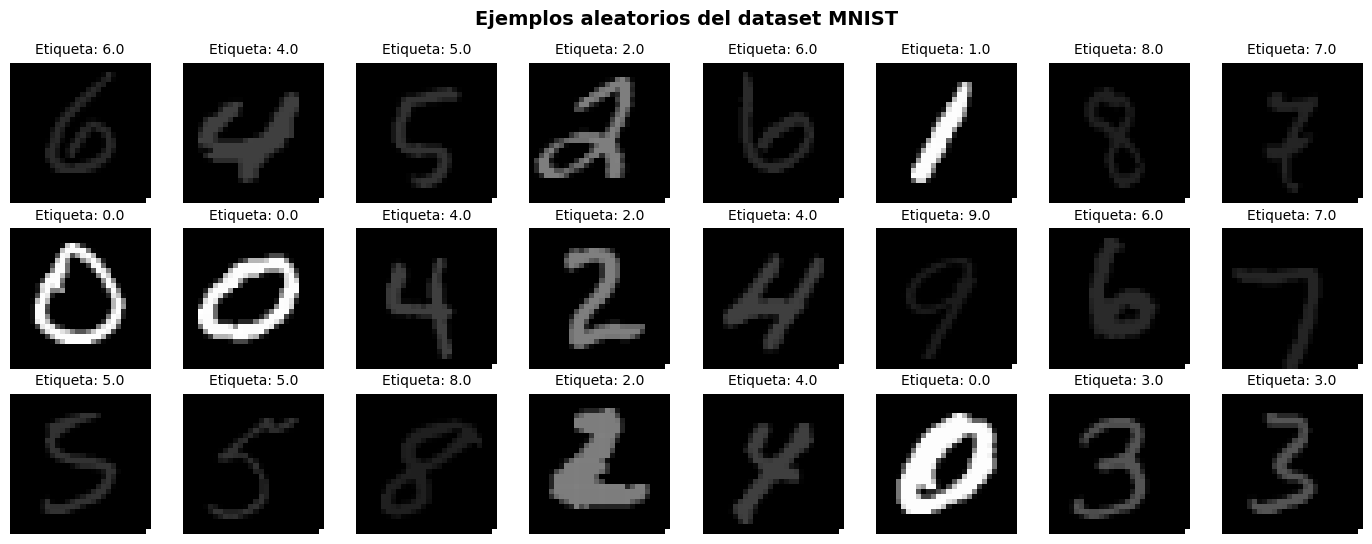

In [23]:
fig, axes = plt.subplots(3, 8, figsize=(14, 5.5))

for ax in axes.flat:
    idx = np.random.randint(0, len(data))
    imagen = data.iloc[idx, 1:].to_numpy().reshape(28, 28)
    etiqueta = data.loc[idx]["label"]
    ax.imshow(imagen, cmap="gray")
    ax.set_title(f"Etiqueta: {etiqueta}", fontsize=10)
    ax.axis("off")

plt.suptitle("Ejemplos aleatorios del dataset MNIST", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Arquitectura de la red

La red es un **perceptrón multicapa** muy sencillo, con dos capas de parámetros:

- **Capa de entrada:** 784 neuronas (una por píxel).
- **Capa oculta:** 64 neuronas con activación **ReLU**.
- **Capa de salida:** 10 neuronas (una por dígito) con activación **Softmax**, que convierte las salidas en probabilidades.

Visualmente:


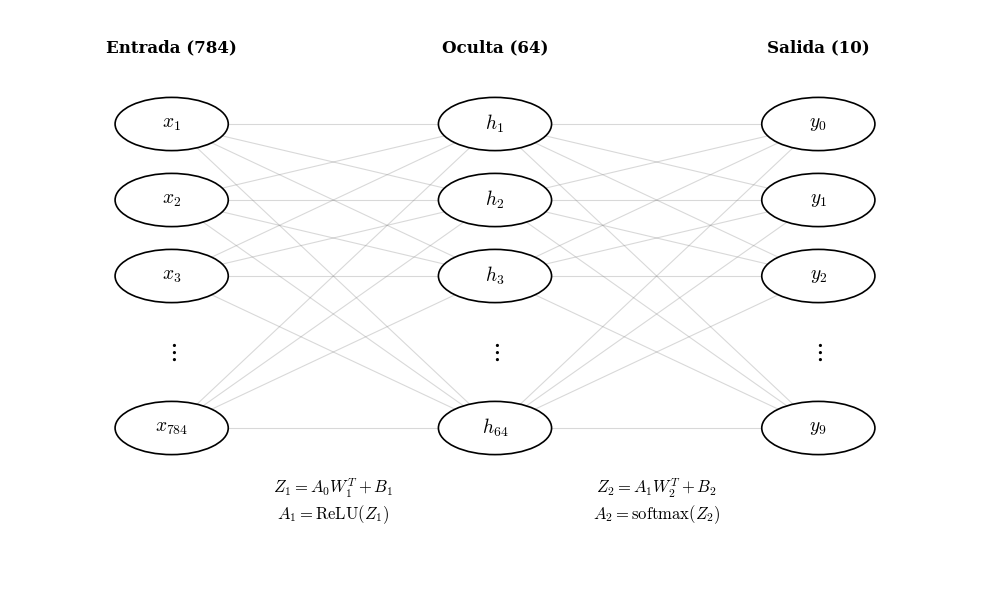

In [24]:
plt.rcParams.update({ "font.family": "serif", "mathtext.fontset": "cm", "axes.unicode_minus": False})

fig, ax = plt.subplots(figsize=(10, 6))

capas = [
    {"x": 0, "nodos": ["$x_1$", "$x_2$", "$x_3$", "$x_{784}$"], "titulo": "Entrada (784)"},
    {"x": 2, "nodos": ["$h_1$", "$h_2$", "$h_3$", "$h_{64}$"], "titulo": "Oculta (64)"},
    {"x": 4, "nodos": ["$y_0$", "$y_1$", "$y_2$", "$y_9$"], "titulo": "Salida (10)"}
]
y_posiciones = [2, 1, 0, -2]
y_puntos = -1 

for i in range(len(capas) - 1):
    x1, x2 = capas[i]["x"], capas[i+1]["x"]
    for y1 in y_posiciones:
        for y2 in y_posiciones:
            ax.plot([x1, x2], [y1, y2], color="gray", alpha=0.3, linewidth=0.8, zorder=1)

for capa in capas:
    x = capa["x"]
    ax.text(x, 3, capa["titulo"], ha="center", va="center", fontsize=12, fontweight="bold")
    for y, etiqueta in zip(y_posiciones, capa["nodos"]):
        circulo = plt.Circle((x, y), 0.35, color="white", ec="black", lw=1.2, zorder=2)
        ax.add_patch(circulo)
        ax.text(x, y, etiqueta, ha="center", va="center", fontsize=14, zorder=3)
    ax.text(x, y_puntos, r"$\vdots$", ha="center", va="center", fontsize=18)

ax.text(1, -3.2, "$Z_1 = A_0 W_1^T + B_1$\n$A_1 = \mathrm{ReLU}(Z_1)$", ha="center", fontsize=12)
ax.text(3, -3.2, "$Z_2 = A_1 W_2^T + B_2$\n$A_2 = \mathrm{softmax}(Z_2)$", ha="center", fontsize=12)

ax.set_xlim(-1, 5)
ax.set_ylim(-4, 3.5)
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Ecuaciones y derivadas

Antes de programar, conviene tener claras las matemáticas del *forward pass* y del *backward pass* (backpropagation), que son las que nos permitirán calcular cómo ajustar los pesos de la red en cada iteración.


### 1. Forward Pass (Propagación hacia adelante)

Aquí calculamos las activaciones capa por capa:

* **Entrada:** $A_0 = X$
* **Capa 1:**
* $Z_1 = A_0 W_1^T + B_1$
* $A_1 = \text{ReLU}(Z_1)$


* **Capa 2 (Salida):**
* $Z_2 = A_1 W_2^T + B_2$
* $A_2 = \text{softmax}(Z_2)$



---

### 2. Backward Pass (Retropropagación)

#### Gradientes en la Capa 2 (Salida)

**Derivada respecto a $W_2$:**
* **Regla de la Cadena:** $\frac{\partial E}{\partial W_2} = \frac{\partial E}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial W_2}$
* **Derivada Final:** $\frac{\partial E}{\partial W_2} = (A_2 - Y)^T \cdot A_1$


**Derivada respecto a $B_2$:**
* **Regla de la Cadena:** $\frac{\partial E}{\partial B_2} = \frac{\partial E}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial B_2}$
* **Derivada Final:** $\frac{\partial E}{\partial B_2} = \sum (A_2 - Y)$



#### Gradientes en la Capa 1 (Oculta)

**Derivada respecto a $W_1$:**
* **Regla de la Cadena:** $\frac{\partial E}{\partial W_1} = \frac{\partial E}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial A_1} \cdot \frac{\partial A_1}{\partial Z_1} \cdot \frac{\partial Z_1}{\partial W_1}$
* **Derivada Final:** $\frac{\partial E}{\partial W_1} = [ (A_2 - Y) \cdot W_2 ] \odot \text{ReLU}'(Z_1)^T \cdot A_0$


**Derivada respecto a $B_1$:**
* **Regla de la Cadena:** $\frac{\partial E}{\partial B_1} = \frac{\partial E}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial A_1} \cdot \frac{\partial A_1}{\partial Z_1} \cdot \frac{\partial Z_1}{\partial B_1}$
* **Derivada Final:** $\frac{\partial E}{\partial B_1} = \sum [ (A_2 - Y) \cdot W_2 ] \odot \text{ReLU}'(Z_1)$



---

### 3. Definiciones Técnicas

* **$Y$**: Vector columna de etiquetas reales (one-hot).
* **$A_2$**: Predicción final de la red (output de Softmax).
* **$\text{ReLU}'(Z_1)$**: Matriz de la misma forma que $Z_1$ con $1$ si $Z_1 > 0$ y $0$ si $Z_1 \le 0$.
* **$\odot$**: Producto de Hadamard (multiplicación elemento a elemento).
* **$T$**: Operación de transposición de matrices.

## 5. Implementación de las funciones

Con las ecuaciones ya definidas, las traducimos directamente a código. Las funciones que vamos a implementar son:

- `relu` y `softmax` $\implies$ las funciones de activación.
- `forward_pass` $\implies$ propaga la entrada por la red y devuelve todas las activaciones intermedias.
- `backward_pass` $\implies$ calcula los gradientes de cada parámetro usando la regla de la cadena.
- `update_parameters` $\implies$ aplica el descenso de gradiente ($\theta = \theta - \alpha \cdot \nabla\theta$).
- `one_hot` $\implies$ convierte una etiqueta (por ejemplo, `7`) en un vector one-hot (`[0,0,0,0,0,0,0,1,0,0]`).
- `get_accuracy` $\implies$ calcula el porcentaje de aciertos.


In [25]:
def relu(Matriz):
    return np.maximum(0, Matriz)

def softmax(Z):
    return np.exp(Z)/np.sum(np.exp(Z), axis=1, keepdims=True)

def forward_pass(A0, W1, W2, B1, B2):
    Z1 = A0 @ W1.T + B1
    A1 = relu(Z1)
    Z2 = A1 @ W2.T + B2
    A2 = softmax(Z2)
    return A0, Z1, A1, Z2, A2


def backward_pass(A0, Z1, A1, Z2, A2, W2, Y):
    m = Y.shape[0] 
    dZ2 = A2 - Y 
    dW2 = (1 / m)*np.dot(dZ2.T, A1)
    dB2 = (1 / m)*np.sum(dZ2, axis=0, keepdims=True)
    dZ1 = np.dot(dZ2, W2)*(Z1 > 0)
    dW1 = (1 / m) * np.dot(dZ1.T, A0)
    dB1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)
    return dW1, dB1, dW2, dB2


def update_parameters(W1, B1, W2, B2, dW1, dB1, dW2, dB2, learning_rate):
    W1 = W1 - learning_rate*dW1
    B1 = B1 - learning_rate*dB1
    W2 = W2 - learning_rate*dW2
    B2 = B2 - learning_rate*dB2
    return W1, B1, W2, B2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, 10))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y

def get_accuracy(predicciones, Y):
    return np.sum(predicciones == Y) / Y.size

## 6. Entrenamiento

Ya con todas las piezas listas, en esta celda:

1. Cargamos y **barajamos** el dataset completo.
2. Separamos las etiquetas (`label`) de los píxeles.
3. Dividimos en **80% entrenamiento / 20% test**, para poder medir el rendimiento sobre datos que la red nunca ha visto.
4. Inicializamos los pesos ($W_1, W_2$) de forma aleatoria y los sesgos ($B_1, B_2$) a cero.
5. Ejecutamos **500 iteraciones** de descenso de gradiente sobre el conjunto de entrenamiento completo (*batch gradient descent*), con `learning_rate = 0.5`.
6. Evaluamos la precisión final sobre el conjunto de test.


In [26]:
df = pd.read_csv('data/mnist_train.csv')
df = df.sample(frac=1).reset_index(drop=True)
Y_pandas = df["label"]
X_pandas = df.drop(columns=["label"])

Y_completo = Y_pandas.to_numpy().astype(int)
X_completo = X_pandas.to_numpy()

split_index = int(len(df)*0.8)

X_train = X_completo[:split_index]
Y_train = Y_completo[:split_index]
Y_train_one_hot = one_hot(Y_train)

X_test = X_completo[split_index:]
Y_test = Y_completo[split_index:]

print(f"Imágenes para entrenar: {X_train.shape[0]}")
print(f"Imágenes para testear: {X_test.shape[0]}\n")

input_size = 784
hidden_size = 64 
output_size = 10 

W1 = np.random.randn(hidden_size, input_size)*0.1
B1 = np.zeros((1, hidden_size))
W2 = np.random.randn(output_size, hidden_size)*0.1
B2 = np.zeros((1, output_size))

iteraciones = 500
learning_rate = 0.50

for i in range(iteraciones):
    A0, Z1, A1, Z2, A2 = forward_pass(X_train, W1, W2, B1, B2)
    dW1, dB1, dW2, dB2 = backward_pass(A0, Z1, A1, Z2, A2, W2, Y_train_one_hot)
    W1, B1, W2, B2 = update_parameters(W1, B1, W2, B2, dW1, dB1, dW2, dB2, learning_rate)
    if i % 50 == 0 or i == iteraciones - 1:
        predicciones = np.argmax(A2, axis=1)
        precision = get_accuracy(predicciones, Y_train)
        print(f"Iteración {i} | Precisión Train: {precision*100:.2f}%")

print("\nEvaluando con imágenes que la red nunca ha visto...")
_, _, _, _, A2_test = forward_pass(X_test, W1, W2, B1, B2)

predicciones_test = np.argmax(A2_test, axis=1)
precision_test = get_accuracy(predicciones_test, Y_test)

print(f"Predicción final en test: {precision_test*100:.2f}%")

Imágenes para entrenar: 48000
Imágenes para testear: 12000

Iteración 0 | Precisión Train: 12.56%
Iteración 50 | Precisión Train: 82.82%
Iteración 100 | Precisión Train: 90.86%
Iteración 150 | Precisión Train: 92.22%
Iteración 200 | Precisión Train: 93.12%
Iteración 250 | Precisión Train: 93.76%
Iteración 300 | Precisión Train: 94.24%
Iteración 350 | Precisión Train: 94.70%
Iteración 400 | Precisión Train: 95.05%
Iteración 450 | Precisión Train: 95.36%
Iteración 499 | Precisión Train: 95.63%

Evaluando con imágenes que la red nunca ha visto...
Predicción final en test: 95.05%


## 7. Resultados y visualización

El entrenamiento terminó con más de un **95% de precisión**, tanto en entrenamiento como en test. Vamos a explorar esos resultados con algunas visualizaciones:

- Una **matriz de confusión**, para ver con qué dígitos se confunde más la red.
- Ejemplos de **predicciones reales** sobre imágenes de test.
- Una mirada a **qué ha aprendido** la capa oculta.


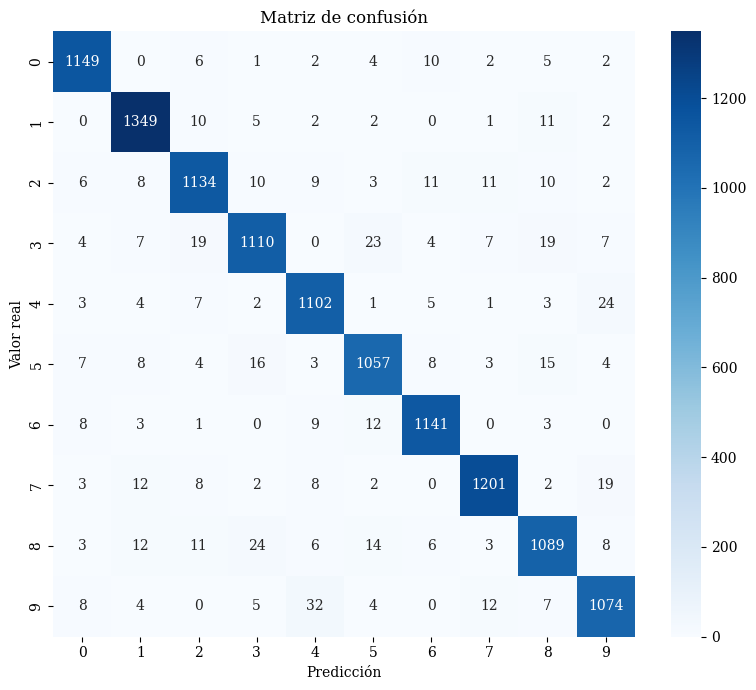

In [27]:
matriz_confusion = np.zeros((10, 10), dtype=int)

for real, prediccion in zip(Y_test, predicciones_test):
    matriz_confusion[real, prediccion] += 1

plt.figure(figsize=(8, 7))
sns.heatmap(matriz_confusion, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

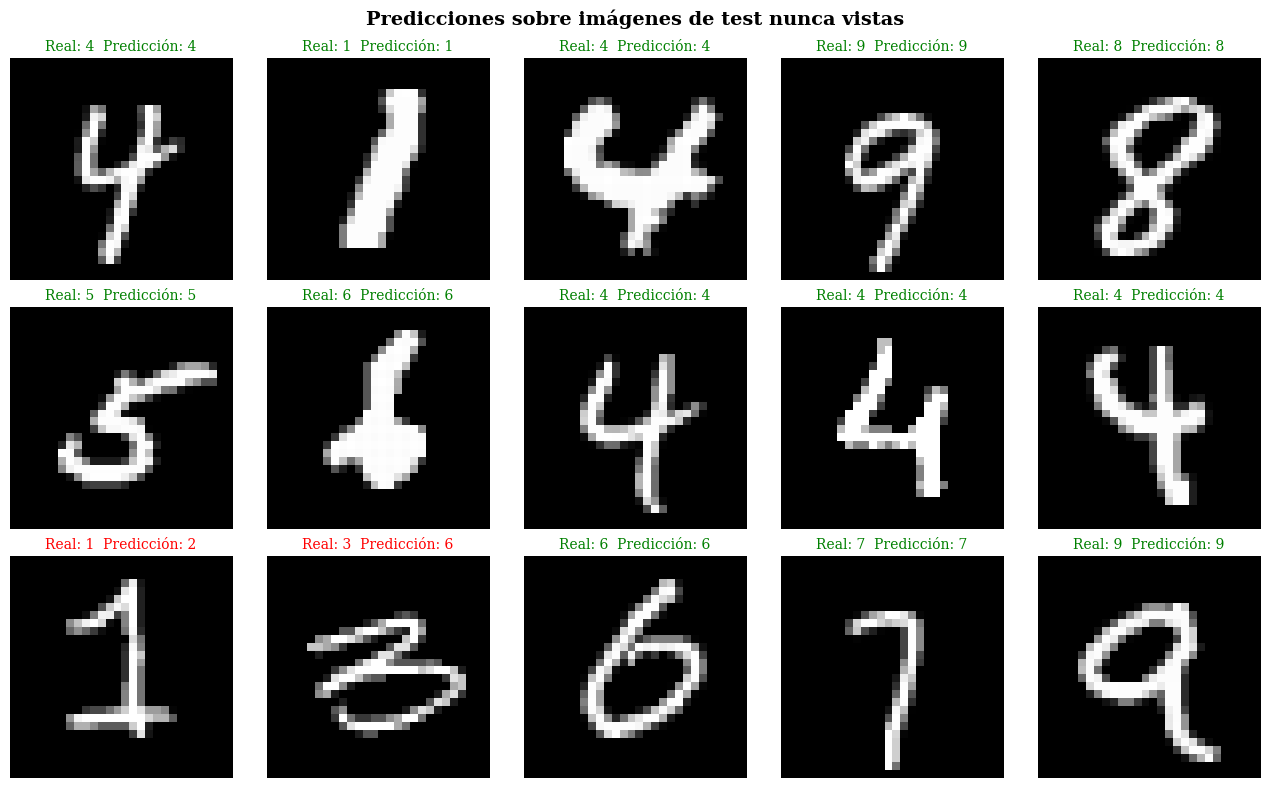

In [28]:
indices = np.random.choice(len(X_test), 15, replace=False)
fig, axes = plt.subplots(3, 5, figsize=(13, 8))

for ax, idx in zip(axes.flat, indices):
    imagen = X_test[idx].reshape(28, 28)
    real = Y_test[idx]
    prediccion = predicciones_test[idx]
    color = "green" if real == prediccion else "red"
    ax.imshow(imagen, cmap="gray")
    ax.set_title(f"Real: {real}  Predicción: {prediccion}", color=color, fontsize=10)
    ax.axis("off")

plt.suptitle("Predicciones sobre imágenes de test nunca vistas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### ¿Qué ha aprendido la capa oculta?

Cada una de las 64 neuronas de la capa oculta tiene un vector de pesos $W_1$ del mismo tamaño que una imagen (784 valores). Si "desaplanamos" cada uno de esos vectores a 28×28, podemos verlos como si fueran pequeños filtros o patrones que la neurona busca en la imagen de entrada.


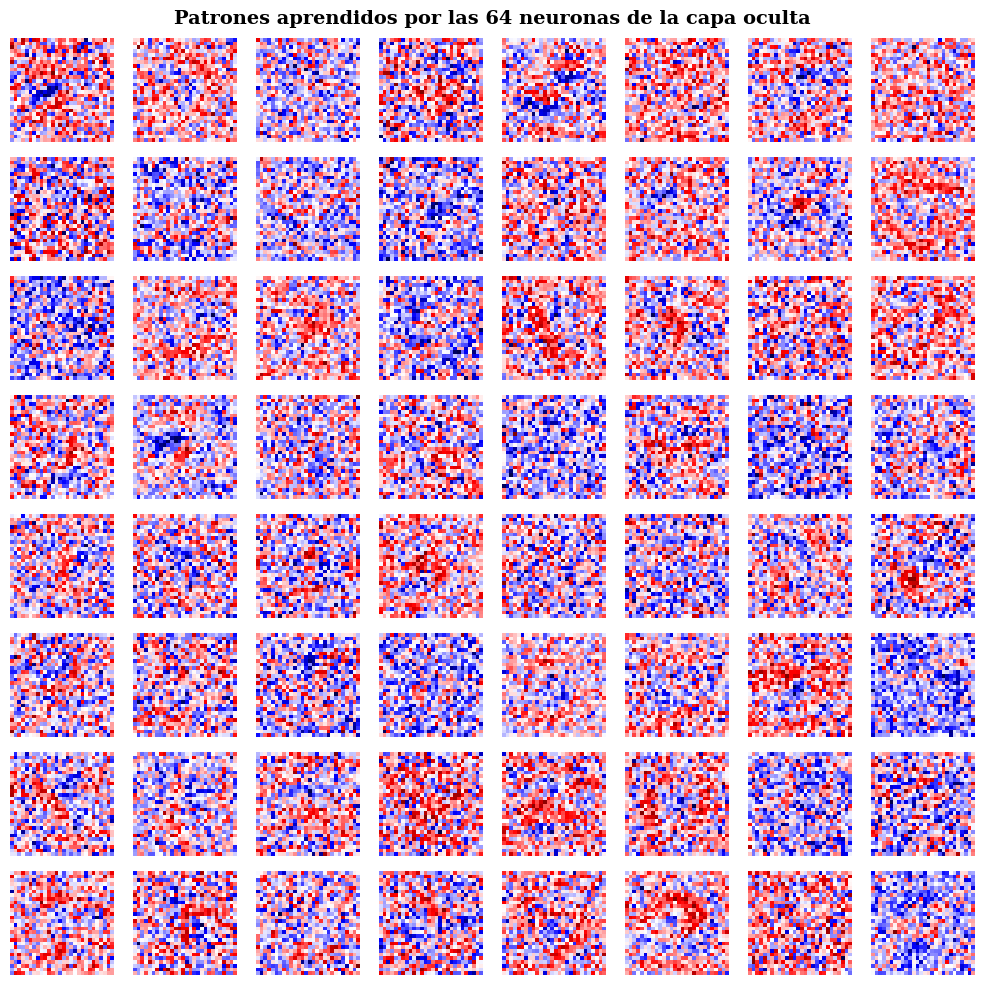

In [29]:
fig, axes = plt.subplots(8, 8, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(W1[i].reshape(28, 28), cmap="seismic")
    ax.axis("off")

plt.suptitle("Patrones aprendidos por las 64 neuronas de la capa oculta", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

A diferencia de las redes convolucionales, en un perceptrón simple cada neurona de la capa oculta está conectada a todos los píxeles de la imagen, por lo que sus pesos no suelen organizarse en patrones fácilmente interpretables como bordes o trazos, incluso con una precisión alta.

## Conclusión

Hemos construido, entrenado y evaluado una red neuronal para MNIST **desde cero**, usando únicamente NumPy:

- Entendimos cómo se representa una imagen como vector de píxeles.
- Definimos matemáticamente el *forward pass* y el *backward pass*.
- Implementamos y entrenamos la red, alcanzando $\approx$ 95% de precisión en test.
- Visualizamos tanto los aciertos/errores como los patrones internos aprendidos por la red.
